In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv("Bitcoin Historical Data (1).csv")
df

,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
...,...,...,...,...,...,...,...
4994,22-07-2010,0.1,0.1,0.1,0.1,2.16K,0.00%
4995,21-07-2010,0.1,0.1,0.1,0.1,0.58K,0.00%
4996,20-07-2010,0.1,0.1,0.1,0.1,0.26K,0.00%
4997,19-07-2010,0.1,0.1,0.1,0.1,0.57K,0.00%


In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

C:\Users\banup\AppData\Local\Temp\ipykernel_13336\1906951153.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


In [5]:
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
df = df.sort_values(by="Date", ascending=True)
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,0.08K,0.00%
4997,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00%
4996,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00%
4995,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00%
4994,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00%


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 4998 to 0
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4999 non-null   datetime64[us]
 1   Price     4999 non-null   str           
 2   Open      4999 non-null   str           
 3   High      4999 non-null   str           
 4   Low       4999 non-null   str           
 5   Vol.      4993 non-null   str           
 6   Change %  4999 non-null   str           
dtypes: datetime64[us](1), str(6)
memory usage: 273.5 KB


In [7]:
# Cleaning price
df['Price'] = df['Price'].astype(str).str.replace(',', '')
df['Price'] = df['Price'].replace('-', np.nan).astype(float)

In [8]:
df["Price"].isna().sum()

np.int64(0)

In [9]:
#split the dataframe to train and test
train_size=int(len(df) * 0.8)

train_df =df.iloc[:train_size]
test_df =df.iloc[train_size:]

print("Training data:",train_df.shape)
print("Testing data :",test_df.shape)


Training data: (3999, 7)
Testing data : (1000, 7)


In [10]:
#scaling
scaler = MinMaxScaler()
scaled_train=scaler.fit_transform(train_df[['Price']])
scaled_test=scaler.transform(test_df[['Price']])

In [11]:
print(scaled_train.shape,scaled_test.ndim)
print(scaled_test.shape,scaled_test.ndim)

(3999, 1) 2
(1000, 1) 2


In [66]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [12]:
def create_sequences(data,seq_length=60):

    X = []
    y = []

    for i in range(len(data)-seq_length-7):

        X.append(data[i:i+seq_length])

        y.append([
            data[i+seq_length,0],      
            data[i+seq_length+3,0],    
            data[i+seq_length+7,0]    
        ])

    return np.array(X), np.array(y)

In [13]:
#train and test sequence
X_train,y_train=create_sequences(scaled_train,seq_length=60)

X_test,y_test=create_sequences(scaled_test,seq_length=60)

print(X_train.shape,type(X_train),X_train.dtype)
print(y_train.shape,type(y_train),y_train.dtype)

print(X_test.shape,type(X_test),X_test.dtype)
print(y_test.shape,type(y_test),y_test.dtype)

(3932, 60, 1) <class 'numpy.ndarray'> float64
(3932, 3) <class 'numpy.ndarray'> float64
(933, 60, 1) <class 'numpy.ndarray'> float64
(933, 3) <class 'numpy.ndarray'> float64


In [14]:
import torch

#create pytorch tensors
X_train_t=torch.tensor(X_train,dtype=torch.float32)
y_train_t=torch.tensor(y_train,dtype=torch.float32)

X_test_t=torch.tensor(X_test,dtype=torch.float32)
y_test_t=torch.tensor(y_test,dtype=torch.float32)

In [15]:
#Tensor dataset and dataloader
from torch.utils.data import TensorDataset, DataLoader

train_dataset=TensorDataset(X_train_t,y_train_t)
test_dataset=TensorDataset(X_test_t,y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [16]:
#LSTM model
import torch.nn as nn

class BitcoinLSTM(nn.Module):
    def __init__(self,input_size=1,hidden_size=64,num_layers=1,output_size=3,dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm=nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
            )
        self.fc1=nn.Linear(hidden_size,32)
        self.relu=nn.ReLU()
        self.dropout=nn.Dropout(dropout)
        self.fc2=nn.Linear(32,output_size)

    def forward(self, x):
        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size,
            device=x.device
        )
        c0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size,
            device=x.device
        )
        out, _ =self.lstm(x, (h0, c0))

        out=out[:, -1, :]
        out=self.fc1(out)
        out=self.relu(out)
        out=self.dropout(out)
        out=self.fc2(out)
        return out

        

In [18]:
#Initialising the model,loss function and optimizer
model=BitcoinLSTM()

criterion=nn.MSELoss()   # regression loss

optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

c:\Users\banup\OneDrive\Desktop\crypto project5\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1009: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [19]:
#LSTM Training loop
epochs = 50

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for X_batch, y_batch in train_loader:
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.6f}")


Epoch [1/50] Loss: 0.014673
Epoch [2/50] Loss: 0.003225
Epoch [3/50] Loss: 0.002178
Epoch [4/50] Loss: 0.001897
Epoch [5/50] Loss: 0.001900
Epoch [6/50] Loss: 0.001636
Epoch [7/50] Loss: 0.001488
Epoch [8/50] Loss: 0.001540
Epoch [9/50] Loss: 0.001438
Epoch [10/50] Loss: 0.001468
Epoch [11/50] Loss: 0.001255
Epoch [12/50] Loss: 0.001238
Epoch [13/50] Loss: 0.001178
Epoch [14/50] Loss: 0.001106
Epoch [15/50] Loss: 0.001217
Epoch [16/50] Loss: 0.001391
Epoch [17/50] Loss: 0.001288
Epoch [18/50] Loss: 0.001142
Epoch [19/50] Loss: 0.001055
Epoch [20/50] Loss: 0.001026
Epoch [21/50] Loss: 0.001079
Epoch [22/50] Loss: 0.001075
Epoch [23/50] Loss: 0.001039
Epoch [24/50] Loss: 0.001017
Epoch [25/50] Loss: 0.001041
Epoch [26/50] Loss: 0.000943
Epoch [27/50] Loss: 0.000905
Epoch [28/50] Loss: 0.000973
Epoch [29/50] Loss: 0.001129
Epoch [30/50] Loss: 0.001055
Epoch [31/50] Loss: 0.001015
Epoch [32/50] Loss: 0.001063
Epoch [33/50] Loss: 0.000848
Epoch [34/50] Loss: 0.001002
Epoch [35/50] Loss: 0.0

In [20]:
#LSTM Model evaluation
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_t)

test_predictions = test_predictions.numpy()
y_test_np = y_test_t.numpy()


pred_1d = scaler.inverse_transform(test_predictions[:, 0].reshape(-1, 1))
pred_3d = scaler.inverse_transform(test_predictions[:, 1].reshape(-1, 1))
pred_7d = scaler.inverse_transform(test_predictions[:, 2].reshape(-1, 1))

actual_1d = scaler.inverse_transform(y_test_t[:, 0].reshape(-1, 1))
actual_3d = scaler.inverse_transform(y_test_t[:, 1].reshape(-1, 1))
actual_7d = scaler.inverse_transform(y_test_t[:, 2].reshape(-1, 1))



In [22]:
#Evaluation Metrics for LSTM
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(pred, actual, horizon):
    mae_LSTM = mean_absolute_error(actual, pred)
    rmse_LSTM = np.sqrt(mean_squared_error(actual, pred))
    r2_LSTM = r2_score(actual, pred)
    print(f"{horizon} MAE: {mae_LSTM:.4f}, RMSE: {rmse_LSTM:.4f}, R²: {r2_LSTM:.4f}")

evaluate(pred_1d, actual_1d, "1-day")
evaluate(pred_3d, actual_3d, "3-day")
evaluate(pred_7d, actual_7d, "7-day")

1-day MAE: 1166.4563, RMSE: 1553.0951, R²: 0.9855
3-day MAE: 1813.2471, RMSE: 2463.0316, R²: 0.9642
7-day MAE: 2566.1818, RMSE: 3451.1171, R²: 0.9310


In [23]:
#Save model parameters
torch.save(model.state_dict(), "bitcoin_lstm.pth")

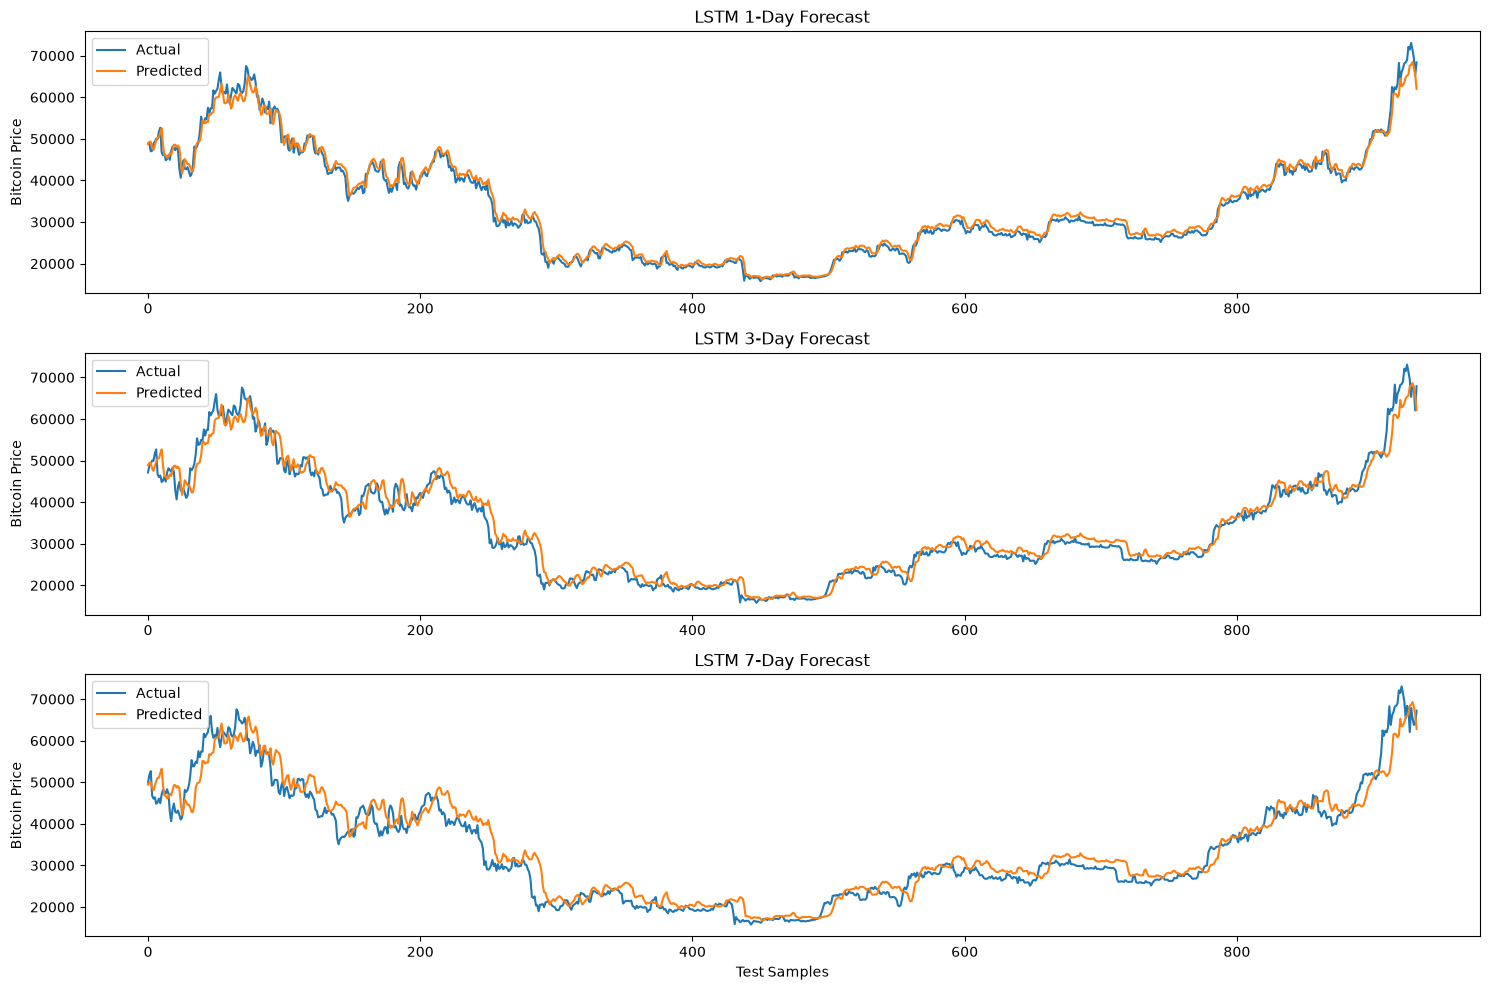

In [24]:
#Visualizing
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

# 1-Day 
plt.subplot(3,1,1)
plt.plot(actual_1d, label="Actual")
plt.plot(pred_1d, label="Predicted")
plt.title("LSTM 1-Day Forecast")
plt.ylabel("Bitcoin Price")
plt.legend()

# 3-Day 
plt.subplot(3,1,2)
plt.plot(actual_3d, label="Actual")
plt.plot(pred_3d, label="Predicted")
plt.title("LSTM 3-Day Forecast")
plt.ylabel("Bitcoin Price")
plt.legend()

# 7-Day 
plt.subplot(3,1,3)
plt.plot(actual_7d, label="Actual")
plt.plot(pred_7d, label="Predicted")
plt.title("LSTM 7-Day Forecast")
plt.xlabel("Test Samples")
plt.ylabel("Bitcoin Price")
plt.legend()

plt.tight_layout()
plt.show()

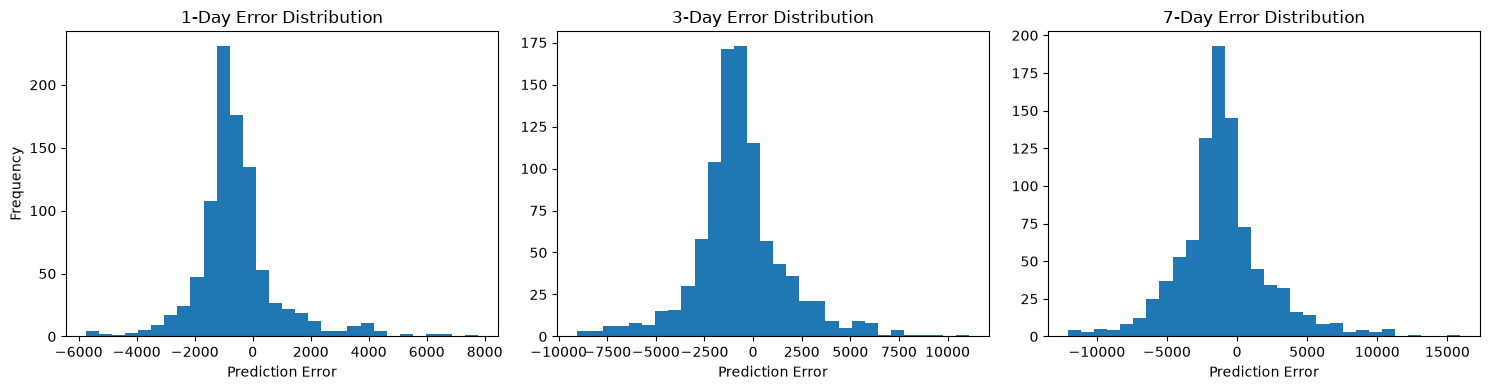

In [25]:
#LSTM Error distribution plot
import matplotlib.pyplot as plt

error_1d_LSTM = actual_1d.flatten() - pred_1d.flatten()
error_3d_LSTM = actual_3d.flatten() - pred_3d.flatten()
error_7d_LSTM = actual_7d.flatten() - pred_7d.flatten()

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(error_1d_LSTM, bins=30)
plt.title("1-Day Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.subplot(1,3,2)
plt.hist(error_3d_LSTM, bins=30)
plt.title("3-Day Error Distribution")
plt.xlabel("Prediction Error")

plt.subplot(1,3,3)
plt.hist(error_7d_LSTM, bins=30)
plt.title("7-Day Error Distribution")
plt.xlabel("Prediction Error")

plt.tight_layout()
plt.show()

In [60]:
#Horizon comparison
# 1-Day
mae_1_LSTM = mean_absolute_error(actual_1d, pred_1d)
rmse_1_LSTM = np.sqrt(mean_squared_error(actual_1d, pred_1d))
r2_1_LSTM = r2_score(actual_1d, pred_1d)

# 3-Day
mae_3_LSTM = mean_absolute_error(actual_3d, pred_3d)
rmse_3_LSTM = np.sqrt(mean_squared_error(actual_3d, pred_3d))
r2_3_LSTM = r2_score(actual_3d, pred_3d)

# 7-Day
mae_7_LSTM = mean_absolute_error(actual_7d, pred_7d)
rmse_7_LSTM = np.sqrt(mean_squared_error(actual_7d, pred_7d))
r2_7_LSTM = r2_score(actual_7d, pred_7d)

comparison = pd.DataFrame({
    "Forecast Horizon": ["1-Day", "3-Day", "7-Day"],
    "MAE": [mae_1_LSTM, mae_3_LSTM, mae_7_LSTM],
    "RMSE": [rmse_1_LSTM, rmse_3_LSTM, rmse_7_LSTM],
    "R2 Score": [r2_1_LSTM, r2_3_LSTM, r2_7_LSTM]
})

print(comparison)

print(f"1-Day MAE: {mae_1_LSTM:.2f}, RMSE: {rmse_1_LSTM:.2f}, R²: {r2_1_LSTM:.4f}")
print(f"3-Day MAE: {mae_3_LSTM:.2f}, RMSE: {rmse_3_LSTM:.2f}, R²: {r2_3_LSTM:.4f}")
print(f"7-Day MAE: {mae_7_LSTM:.2f}, RMSE: {rmse_7_LSTM:.2f}, R²: {r2_7_LSTM:.4f}")

  Forecast Horizon          MAE         RMSE  R2 Score
0            1-Day  1166.456297  1553.095101  0.985525
1            3-Day  1813.247103  2463.031628  0.964165
2            7-Day  2566.181781  3451.117092  0.930971
1-Day MAE: 1166.46, RMSE: 1553.10, R²: 0.9855
3-Day MAE: 1813.25, RMSE: 2463.03, R²: 0.9642
7-Day MAE: 2566.18, RMSE: 3451.12, R²: 0.9310


In [27]:
#CNN Model
class BitcoinCNN(nn.Module):

    def __init__(self,input_channels=1,output_size=3):
        super().__init__()
        self.conv1=nn.Conv1d(
            in_channels=input_channels,
            out_channels=32,
            kernel_size=3
        )
        self.relu = nn.ReLU()
        
        self.conv2 = nn.Conv1d(
            in_channels=32,
            out_channels=64,
            kernel_size=3
        )
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(1792, 64)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(64, output_size)

    def forward(self, x):
        x = x.permute(0,2,1)

        x = self.conv1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.relu(x)
        
        x = self.pool(x)
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x


In [28]:
#Initialising the model,loss function and optimizer
model_CNN=BitcoinCNN()

criterion_CNN=nn.MSELoss()  

optimizer_CNN=torch.optim.Adam(model_CNN.parameters(),lr=0.001)

In [29]:
#CNN Training loop
epochs_CNN = 50

for epoch in range(epochs_CNN):
    model_CNN.train()
    running_loss_CNN = 0

    for X_batch, y_batch in train_loader:
        predictions_CNN = model_CNN(X_batch)
        loss_CNN = criterion_CNN(predictions_CNN, y_batch)
        optimizer_CNN.zero_grad()
        loss_CNN.backward()
        optimizer_CNN.step()
        running_loss_CNN += loss_CNN.item()

    epoch_loss_CNN = running_loss_CNN / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs_CNN}] Loss: {epoch_loss_CNN:.6f}")


Epoch [1/50] Loss: 0.003088
Epoch [2/50] Loss: 0.001700
Epoch [3/50] Loss: 0.001721
Epoch [4/50] Loss: 0.001285
Epoch [5/50] Loss: 0.001485
Epoch [6/50] Loss: 0.001366
Epoch [7/50] Loss: 0.001161
Epoch [8/50] Loss: 0.001019
Epoch [9/50] Loss: 0.001146
Epoch [10/50] Loss: 0.001298
Epoch [11/50] Loss: 0.001011
Epoch [12/50] Loss: 0.000922
Epoch [13/50] Loss: 0.001230
Epoch [14/50] Loss: 0.000992
Epoch [15/50] Loss: 0.001051
Epoch [16/50] Loss: 0.001048
Epoch [17/50] Loss: 0.000941
Epoch [18/50] Loss: 0.000914
Epoch [19/50] Loss: 0.000991
Epoch [20/50] Loss: 0.001114
Epoch [21/50] Loss: 0.000902
Epoch [22/50] Loss: 0.000840
Epoch [23/50] Loss: 0.001097
Epoch [24/50] Loss: 0.000710
Epoch [25/50] Loss: 0.000894
Epoch [26/50] Loss: 0.000885
Epoch [27/50] Loss: 0.000770
Epoch [28/50] Loss: 0.000727
Epoch [29/50] Loss: 0.000980
Epoch [30/50] Loss: 0.000773
Epoch [31/50] Loss: 0.000745
Epoch [32/50] Loss: 0.000678
Epoch [33/50] Loss: 0.000756
Epoch [34/50] Loss: 0.000677
Epoch [35/50] Loss: 0.0

In [30]:
model_CNN.eval()
with torch.no_grad():
    test_preds_CNN = model_CNN(X_test_t) 

test_preds_CNN = test_preds_CNN.numpy()
y_test_np_CNN = y_test_t.numpy()

# Inverse transform predictions
pred_1d_CNN = scaler.inverse_transform(test_preds_CNN[:,0].reshape(-1,1))
pred_3d_CNN = scaler.inverse_transform(test_preds_CNN[:,1].reshape(-1,1))
pred_7d_CNN = scaler.inverse_transform(test_preds_CNN[:,2].reshape(-1,1))

actual_1d_CNN = scaler.inverse_transform(y_test_np_CNN[:,0].reshape(-1,1))
actual_3d_CNN = scaler.inverse_transform(y_test_np_CNN[:,1].reshape(-1,1))
actual_7d_CNN = scaler.inverse_transform(y_test_np_CNN[:,2].reshape(-1,1))

In [31]:
#Save model parameters
torch.save(model_CNN.state_dict(), "bitcoin_cnn.pth")

In [33]:
#CNN evaluation metrics
# 1-Day
mae_1_CNN = mean_absolute_error(actual_1d_CNN, pred_1d_CNN)
rmse_1_CNN = np.sqrt(mean_squared_error(actual_1d_CNN, pred_1d_CNN))
r2_1_CNN = r2_score(actual_1d_CNN, pred_1d_CNN)

# 3-Day
mae_3_CNN = mean_absolute_error(actual_3d_CNN, pred_3d_CNN)
rmse_3_CNN = np.sqrt(mean_squared_error(actual_3d_CNN, pred_3d_CNN))
r2_3_CNN = r2_score(actual_3d_CNN, pred_3d_CNN)

# 7-Day
mae_7_CNN = mean_absolute_error(actual_7d_CNN, pred_7d_CNN)
rmse_7_CNN = np.sqrt(mean_squared_error(actual_7d_CNN, pred_7d_CNN))
r2_7_CNN = r2_score(actual_7d_CNN, pred_7d_CNN)

print(f"1-Day MAE: {mae_1_CNN:.2f}, RMSE: {rmse_1_CNN:.2f}, R²: {r2_1_CNN:.4f}")
print(f"3-Day MAE: {mae_3_CNN:.2f}, RMSE: {rmse_3_CNN:.2f}, R²: {r2_3_CNN:.4f}")
print(f"7-Day MAE: {mae_7_CNN:.2f}, RMSE: {rmse_7_CNN:.2f}, R²: {r2_7_CNN:.4f}")

1-Day MAE: 4279.88, RMSE: 5006.48, R²: 0.8496
3-Day MAE: 5060.75, RMSE: 5800.93, R²: 0.8012
7-Day MAE: 5762.63, RMSE: 6576.78, R²: 0.7493


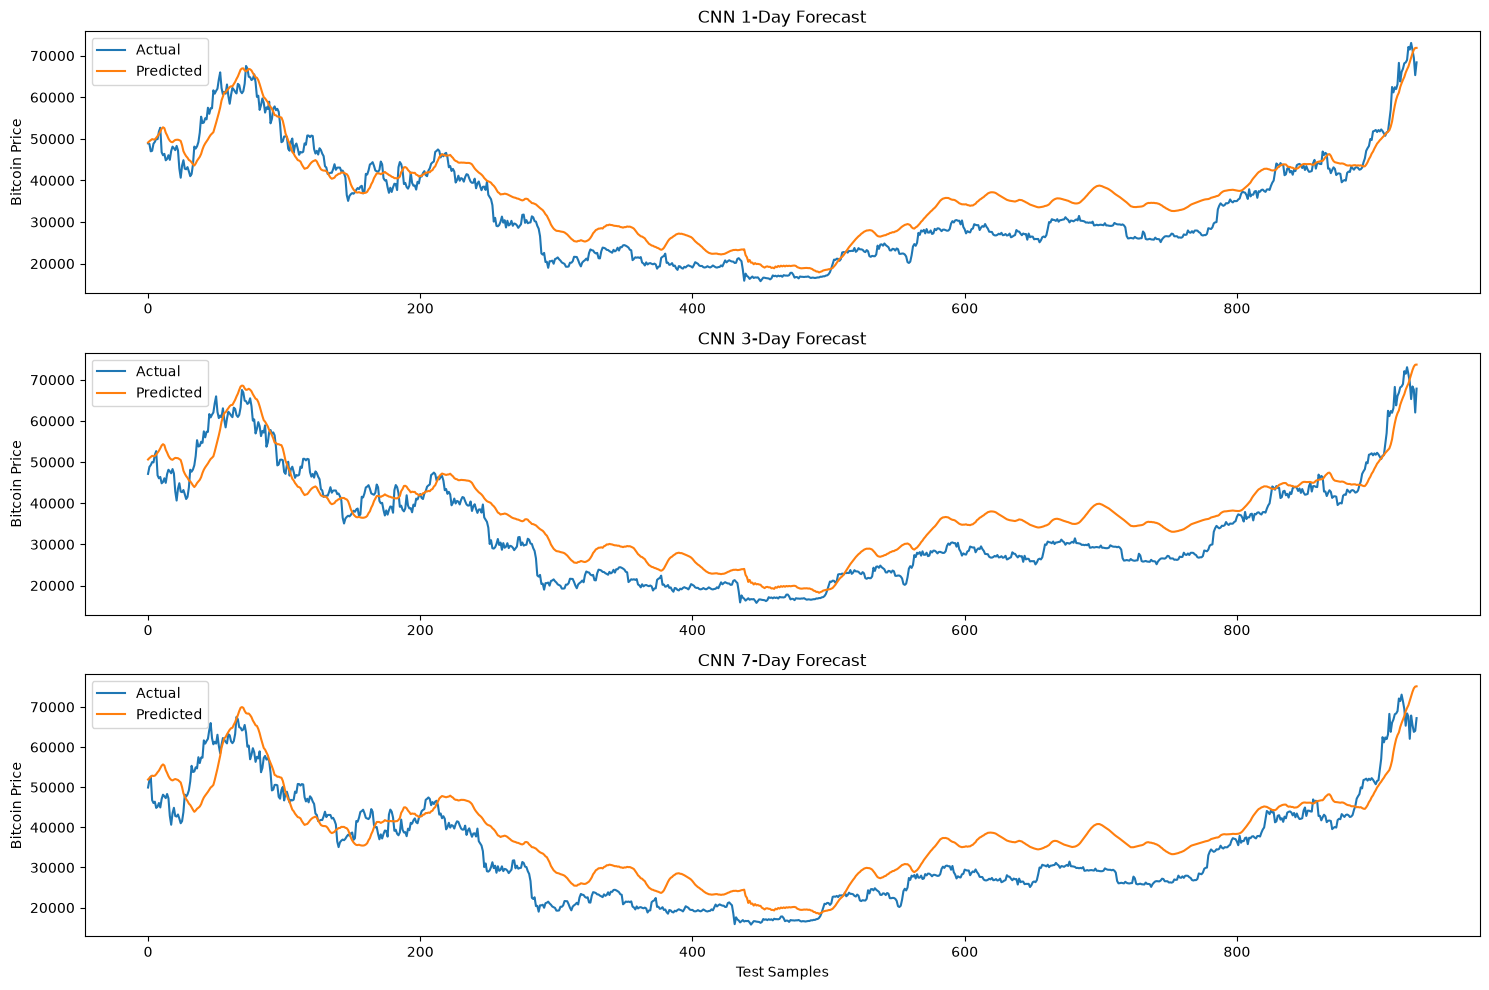

In [55]:
#CNN Visualization

plt.figure(figsize=(15,10))

# 1-Day 
plt.subplot(3,1,1)
plt.plot(actual_1d_CNN, label="Actual")
plt.plot(pred_1d_CNN, label="Predicted")
plt.title("CNN 1-Day Forecast")
plt.ylabel("Bitcoin Price")
plt.legend()

# 3-Day 
plt.subplot(3,1,2)
plt.plot(actual_3d_CNN, label="Actual")
plt.plot(pred_3d_CNN, label="Predicted")
plt.title("CNN 3-Day Forecast")
plt.ylabel("Bitcoin Price")
plt.legend()

# 7-Day 
plt.subplot(3,1,3)
plt.plot(actual_7d_CNN, label="Actual")
plt.plot(pred_7d_CNN, label="Predicted")
plt.title("CNN 7-Day Forecast")
plt.xlabel("Test Samples")
plt.ylabel("Bitcoin Price")
plt.legend()

plt.tight_layout()
plt.show()

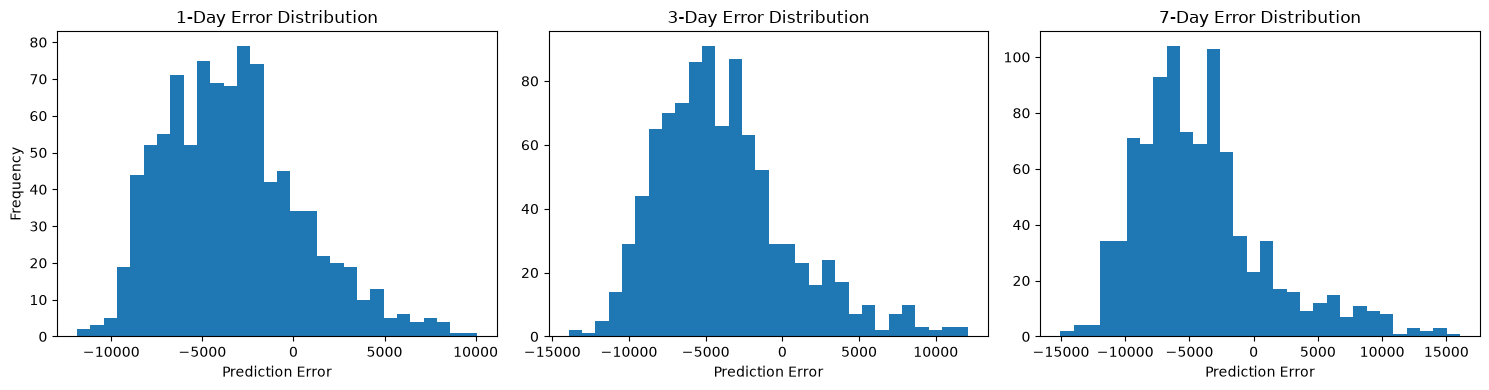

In [36]:
#CNN Error distribution plot

error_1d_CNN = actual_1d_CNN.flatten() - pred_1d_CNN.flatten()
error_3d_CNN = actual_3d_CNN.flatten() - pred_3d_CNN.flatten()
error_7d_CNN = actual_7d_CNN.flatten() - pred_7d_CNN.flatten()

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(error_1d_CNN, bins=30)
plt.title("1-Day Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.subplot(1,3,2)
plt.hist(error_3d_CNN, bins=30)
plt.title("3-Day Error Distribution")
plt.xlabel("Prediction Error")

plt.subplot(1,3,3)
plt.hist(error_7d_CNN, bins=30)
plt.title("7-Day Error Distribution")
plt.xlabel("Prediction Error")

plt.tight_layout()
plt.show()

In [37]:
#RNN Model
class BitcoinRNN(nn.Module):

    def __init__(self,input_size=1,hidden_size=64,num_layers=1,output_size=3,dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):
        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size,
            device=x.device
        )

        out,_ = self.rnn(x, h0)
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)

        return out

In [38]:
#Initialising the model,loss function and optimizer
model_RNN = BitcoinRNN()

criterion_RNN = nn.MSELoss()

optimizer_RNN = torch.optim.Adam(model_RNN.parameters(),lr=0.001)

In [40]:
#RNN Training
epochs_RNN = 50

for epoch in range(epochs_RNN):
    model_RNN.train()
    running_loss_RNN = 0

    for X_batch, y_batch in train_loader:
        predictions_RNN = model_RNN(X_batch)
        loss_RNN = criterion_RNN(predictions_RNN, y_batch)
        optimizer_RNN.zero_grad()
        loss_RNN.backward()
        optimizer_RNN.step()
        running_loss_RNN += loss_RNN.item()

    epoch_loss_RNN = running_loss_RNN / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs_RNN}] Loss: {epoch_loss_RNN:.6f}")

Epoch [1/50] Loss: 0.001552
Epoch [2/50] Loss: 0.001458
Epoch [3/50] Loss: 0.001468
Epoch [4/50] Loss: 0.001165
Epoch [5/50] Loss: 0.001211
Epoch [6/50] Loss: 0.001173
Epoch [7/50] Loss: 0.001313
Epoch [8/50] Loss: 0.001238
Epoch [9/50] Loss: 0.001130
Epoch [10/50] Loss: 0.000923
Epoch [11/50] Loss: 0.001024
Epoch [12/50] Loss: 0.000903
Epoch [13/50] Loss: 0.000959
Epoch [14/50] Loss: 0.000938
Epoch [15/50] Loss: 0.001083
Epoch [16/50] Loss: 0.000943
Epoch [17/50] Loss: 0.000833
Epoch [18/50] Loss: 0.000886
Epoch [19/50] Loss: 0.000917
Epoch [20/50] Loss: 0.000995
Epoch [21/50] Loss: 0.001020
Epoch [22/50] Loss: 0.000860
Epoch [23/50] Loss: 0.000776
Epoch [24/50] Loss: 0.000830
Epoch [25/50] Loss: 0.000970
Epoch [26/50] Loss: 0.000966
Epoch [27/50] Loss: 0.001027
Epoch [28/50] Loss: 0.000975
Epoch [29/50] Loss: 0.000917
Epoch [30/50] Loss: 0.000821
Epoch [31/50] Loss: 0.001053
Epoch [32/50] Loss: 0.000931
Epoch [33/50] Loss: 0.000867
Epoch [34/50] Loss: 0.000760
Epoch [35/50] Loss: 0.0

In [41]:
#CNN Model evaluation
model_RNN.eval()

with torch.no_grad():
    test_preds_RNN = model_RNN(X_test_t)

test_preds_RNN = test_preds_RNN.cpu().numpy()
y_test_np_RNN = y_test_t.cpu().numpy()

pred_1d_RNN = scaler.inverse_transform(test_preds_RNN[:, 0].reshape(-1, 1))
pred_3d_RNN = scaler.inverse_transform(test_preds_RNN[:, 1].reshape(-1, 1))
pred_7d_RNN = scaler.inverse_transform(test_preds_RNN[:, 2].reshape(-1, 1))

actual_1d_RNN = scaler.inverse_transform(y_test_np_RNN[:, 0].reshape(-1, 1))
actual_3d_RNN = scaler.inverse_transform(y_test_np_RNN[:, 1].reshape(-1, 1))
actual_7d_RNN = scaler.inverse_transform(y_test_np_RNN[:, 2].reshape(-1, 1))

In [42]:
#Save model parameters
torch.save(model_RNN.state_dict(), "bitcoin_rnn.pth")

In [43]:
#RNN Evaluation Metrics

# 1-Day
mae_1_RNN = mean_absolute_error(actual_1d_RNN, pred_1d_RNN)
rmse_1_RNN = np.sqrt(mean_squared_error(actual_1d_RNN, pred_1d_RNN))
r2_1_RNN = r2_score(actual_1d_RNN, pred_1d_RNN)

# 3-Day
mae_3_RNN = mean_absolute_error(actual_3d_RNN, pred_3d_RNN)
rmse_3_RNN = np.sqrt(mean_squared_error(actual_3d_RNN, pred_3d_RNN))
r2_3_RNN = r2_score(actual_3d_RNN, pred_3d_RNN)

# 7-Day
mae_7_RNN = mean_absolute_error(actual_7d_RNN, pred_7d_RNN)
rmse_7_RNN = np.sqrt(mean_squared_error(actual_7d_RNN, pred_7d_RNN))
r2_7_RNN = r2_score(actual_7d_RNN, pred_7d_RNN)

print(f"1-Day MAE: {mae_1_RNN:.2f}, RMSE: {rmse_1_RNN:.2f}, R²: {r2_1_RNN:.4f}")
print(f"3-Day MAE: {mae_3_RNN:.2f}, RMSE: {rmse_3_RNN:.2f}, R²: {r2_3_RNN:.4f}")
print(f"7-Day MAE: {mae_7_RNN:.2f}, RMSE: {rmse_7_RNN:.2f}, R²: {r2_7_RNN:.4f}")

1-Day MAE: 1055.84, RMSE: 1414.68, R²: 0.9880
3-Day MAE: 1639.62, RMSE: 2303.60, R²: 0.9687
7-Day MAE: 2219.38, RMSE: 3223.06, R²: 0.9398


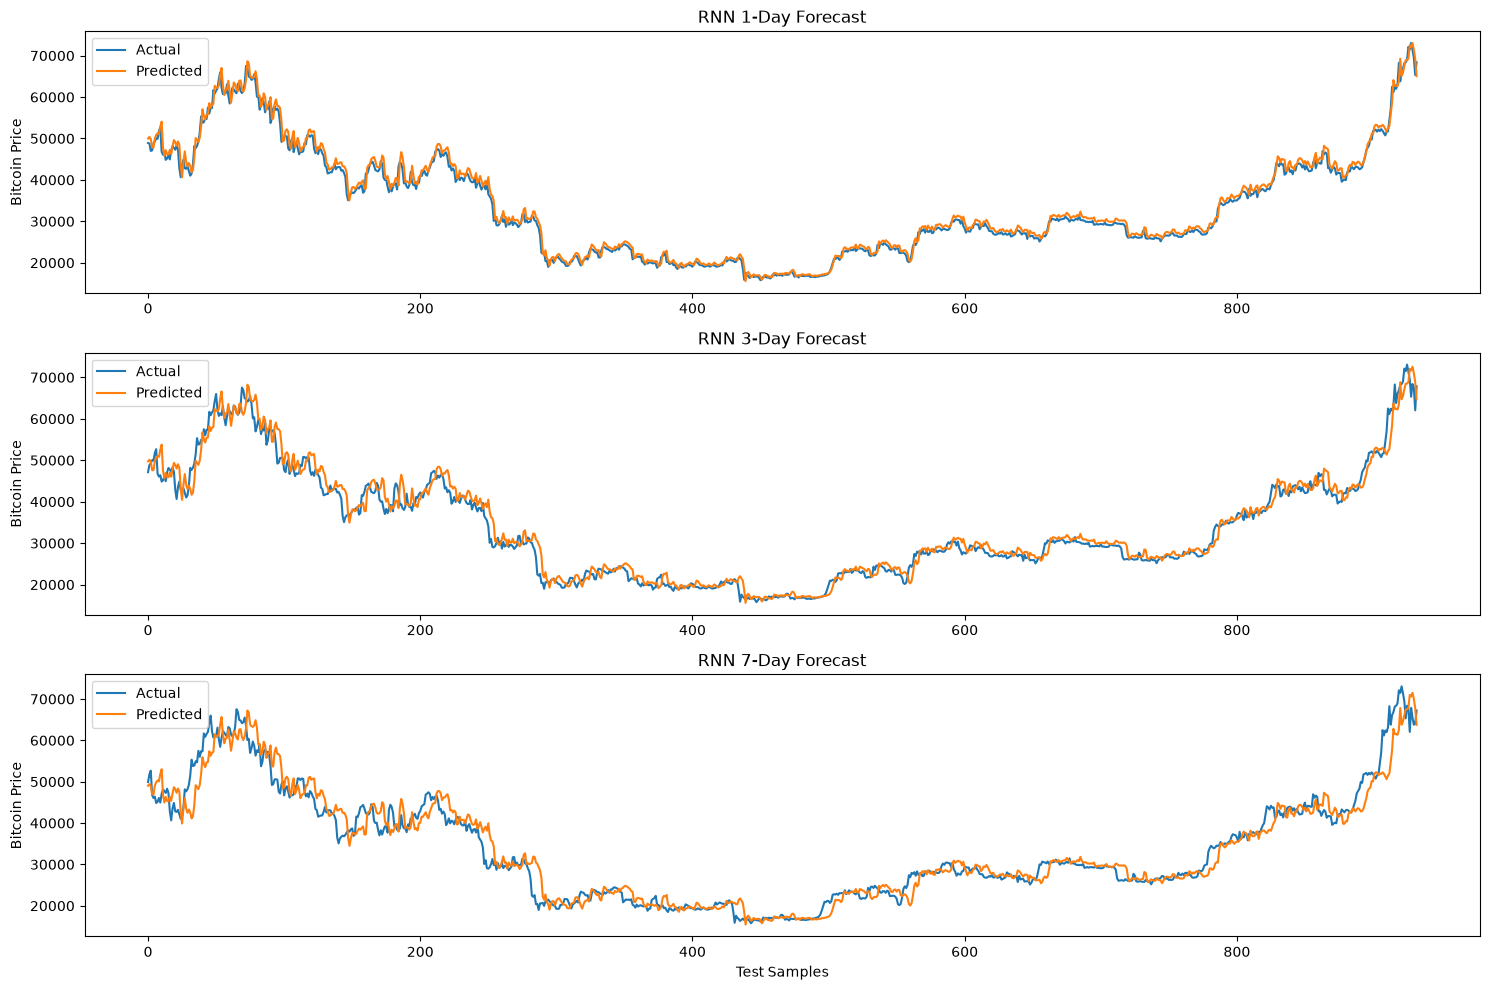

In [54]:
#RNN Visualization

plt.figure(figsize=(15,10))

# 1-Day 
plt.subplot(3,1,1)
plt.plot(actual_1d_RNN, label="Actual")
plt.plot(pred_1d_RNN, label="Predicted")
plt.title("RNN 1-Day Forecast")
plt.ylabel("Bitcoin Price")
plt.legend()

# 3-Day 
plt.subplot(3,1,2)
plt.plot(actual_3d_RNN, label="Actual")
plt.plot(pred_3d_RNN, label="Predicted")
plt.title("RNN 3-Day Forecast")
plt.ylabel("Bitcoin Price")
plt.legend()

# 7-Day 
plt.subplot(3,1,3)
plt.plot(actual_7d_RNN, label="Actual")
plt.plot(pred_7d_RNN, label="Predicted")
plt.title("RNN 7-Day Forecast")
plt.xlabel("Test Samples")
plt.ylabel("Bitcoin Price")
plt.legend()

plt.tight_layout()
plt.show()

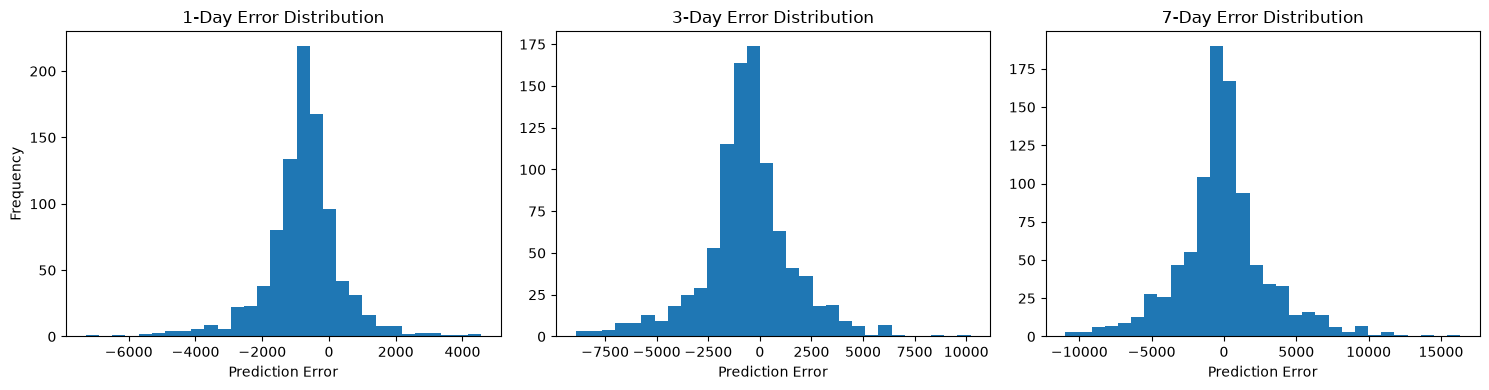

In [45]:
#RNN Error distribution plot

error_1d_RNN = actual_1d_RNN.flatten() - pred_1d_RNN.flatten()
error_3d_RNN = actual_3d_RNN.flatten() - pred_3d_RNN.flatten()
error_7d_RNN = actual_7d_RNN.flatten() - pred_7d_RNN.flatten()

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(error_1d_RNN, bins=30)
plt.title("1-Day Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.subplot(1,3,2)
plt.hist(error_3d_RNN, bins=30)
plt.title("3-Day Error Distribution")
plt.xlabel("Prediction Error")

plt.subplot(1,3,3)
plt.hist(error_7d_RNN, bins=30)
plt.title("7-Day Error Distribution")
plt.xlabel("Prediction Error")

plt.tight_layout()
plt.show()

In [46]:
#Transformer Model
class BitcoinTransformer(nn.Module):

    def __init__(self,input_size=1,d_model=64,nhead=4,num_layers=2,dim_feedforward=128,dropout=0.2,
                 output_size=3):
        super().__init__()
        self.input_projection = nn.Linear(input_size, d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model,nhead=nhead,dim_feedforward=dim_feedforward,
            dropout=dropout,batch_first=True)

        self.transformer = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)
        self.fc1 = nn.Linear(d_model, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [47]:
#Initialising the model,loss function and optimizer
model_TRANS = BitcoinTransformer()

criterion_TRANS = nn.MSELoss()

optimizer_TRANS = torch.optim.Adam(model_TRANS.parameters(),lr=0.001)

In [48]:
#Transformer Training
epochs_TRANS = 50

for epoch in range(epochs_TRANS):
    model_TRANS.train()
    running_loss_TRANS = 0
    for X_batch, y_batch in train_loader:
        predictions_TRANS = model_TRANS(X_batch)
        loss_TRANS = criterion_TRANS(predictions_TRANS, y_batch)
        optimizer_TRANS.zero_grad()
        loss_TRANS.backward()
        optimizer_TRANS.step()
        running_loss_TRANS += loss_TRANS.item()

    print(f"Epoch [{epoch+1}/{epochs_TRANS}] Loss: {running_loss_TRANS/len(train_loader):.6f}")

Epoch [1/50] Loss: 0.011538
Epoch [2/50] Loss: 0.004217
Epoch [3/50] Loss: 0.003613
Epoch [4/50] Loss: 0.003075
Epoch [5/50] Loss: 0.002778
Epoch [6/50] Loss: 0.001847
Epoch [7/50] Loss: 0.002268
Epoch [8/50] Loss: 0.001839
Epoch [9/50] Loss: 0.002011
Epoch [10/50] Loss: 0.001855
Epoch [11/50] Loss: 0.002029
Epoch [12/50] Loss: 0.001716
Epoch [13/50] Loss: 0.001936
Epoch [14/50] Loss: 0.001665
Epoch [15/50] Loss: 0.001582
Epoch [16/50] Loss: 0.001695
Epoch [17/50] Loss: 0.001692
Epoch [18/50] Loss: 0.001730
Epoch [19/50] Loss: 0.001982
Epoch [20/50] Loss: 0.001825
Epoch [21/50] Loss: 0.001329
Epoch [22/50] Loss: 0.001548
Epoch [23/50] Loss: 0.001602
Epoch [24/50] Loss: 0.001952
Epoch [25/50] Loss: 0.001853
Epoch [26/50] Loss: 0.001405
Epoch [27/50] Loss: 0.001792
Epoch [28/50] Loss: 0.001495
Epoch [29/50] Loss: 0.001530
Epoch [30/50] Loss: 0.001494
Epoch [31/50] Loss: 0.001508
Epoch [32/50] Loss: 0.001460
Epoch [33/50] Loss: 0.001636
Epoch [34/50] Loss: 0.001468
Epoch [35/50] Loss: 0.0

In [49]:
#Transformer Evaluation
model_TRANS.eval()

with torch.no_grad():
    test_preds_TRANS = model_TRANS(X_test_t)

test_preds_TRANS = test_preds_TRANS.cpu().numpy()
y_test_np_TRANS = y_test_t.cpu().numpy()

pred_1d_TRANS = scaler.inverse_transform(test_preds_TRANS[:,0].reshape(-1,1))
pred_3d_TRANS = scaler.inverse_transform(test_preds_TRANS[:,1].reshape(-1,1))
pred_7d_TRANS = scaler.inverse_transform(test_preds_TRANS[:,2].reshape(-1,1))

actual_1d_TRANS = scaler.inverse_transform(y_test_np_TRANS[:,0].reshape(-1,1))
actual_3d_TRANS = scaler.inverse_transform(y_test_np_TRANS[:,1].reshape(-1,1))
actual_7d_TRANS = scaler.inverse_transform(y_test_np_TRANS[:,2].reshape(-1,1))

In [50]:
#Save model parameters
torch.save(model_TRANS.state_dict(), "bitcoin_trans.pth")

In [51]:
#Transformer Evaluation Metrics

# 1-Day
mae_1_TRANS = mean_absolute_error(actual_1d_TRANS, pred_1d_TRANS)
rmse_1_TRANS = np.sqrt(mean_squared_error(actual_1d_TRANS, pred_1d_TRANS))
r2_1_TRANS = r2_score(actual_1d_TRANS, pred_1d_TRANS)

# 3-Day
mae_3_TRANS = mean_absolute_error(actual_3d_TRANS, pred_3d_TRANS)
rmse_3_TRANS = np.sqrt(mean_squared_error(actual_3d_TRANS, pred_3d_TRANS))
r2_3_TRANS = r2_score(actual_3d_TRANS, pred_3d_TRANS)

# 7-Day
mae_7_TRANS = mean_absolute_error(actual_7d_TRANS, pred_7d_TRANS)
rmse_7_TRANS = np.sqrt(mean_squared_error(actual_7d_TRANS, pred_7d_TRANS))
r2_7_TRANS = r2_score(actual_7d_TRANS, pred_7d_TRANS)

print(f"1-Day MAE: {mae_1_TRANS:.2f}, RMSE: {rmse_1_TRANS:.2f}, R²: {r2_1_TRANS:.4f}")
print(f"3-Day MAE: {mae_3_TRANS:.2f}, RMSE: {rmse_3_TRANS:.2f}, R²: {r2_3_TRANS:.4f}")
print(f"7-Day MAE: {mae_7_TRANS:.2f}, RMSE: {rmse_7_TRANS:.2f}, R²: {r2_7_TRANS:.4f}")

1-Day MAE: 1310.58, RMSE: 1827.02, R²: 0.9800
3-Day MAE: 1844.72, RMSE: 2604.75, R²: 0.9599
7-Day MAE: 2322.63, RMSE: 3315.57, R²: 0.9363


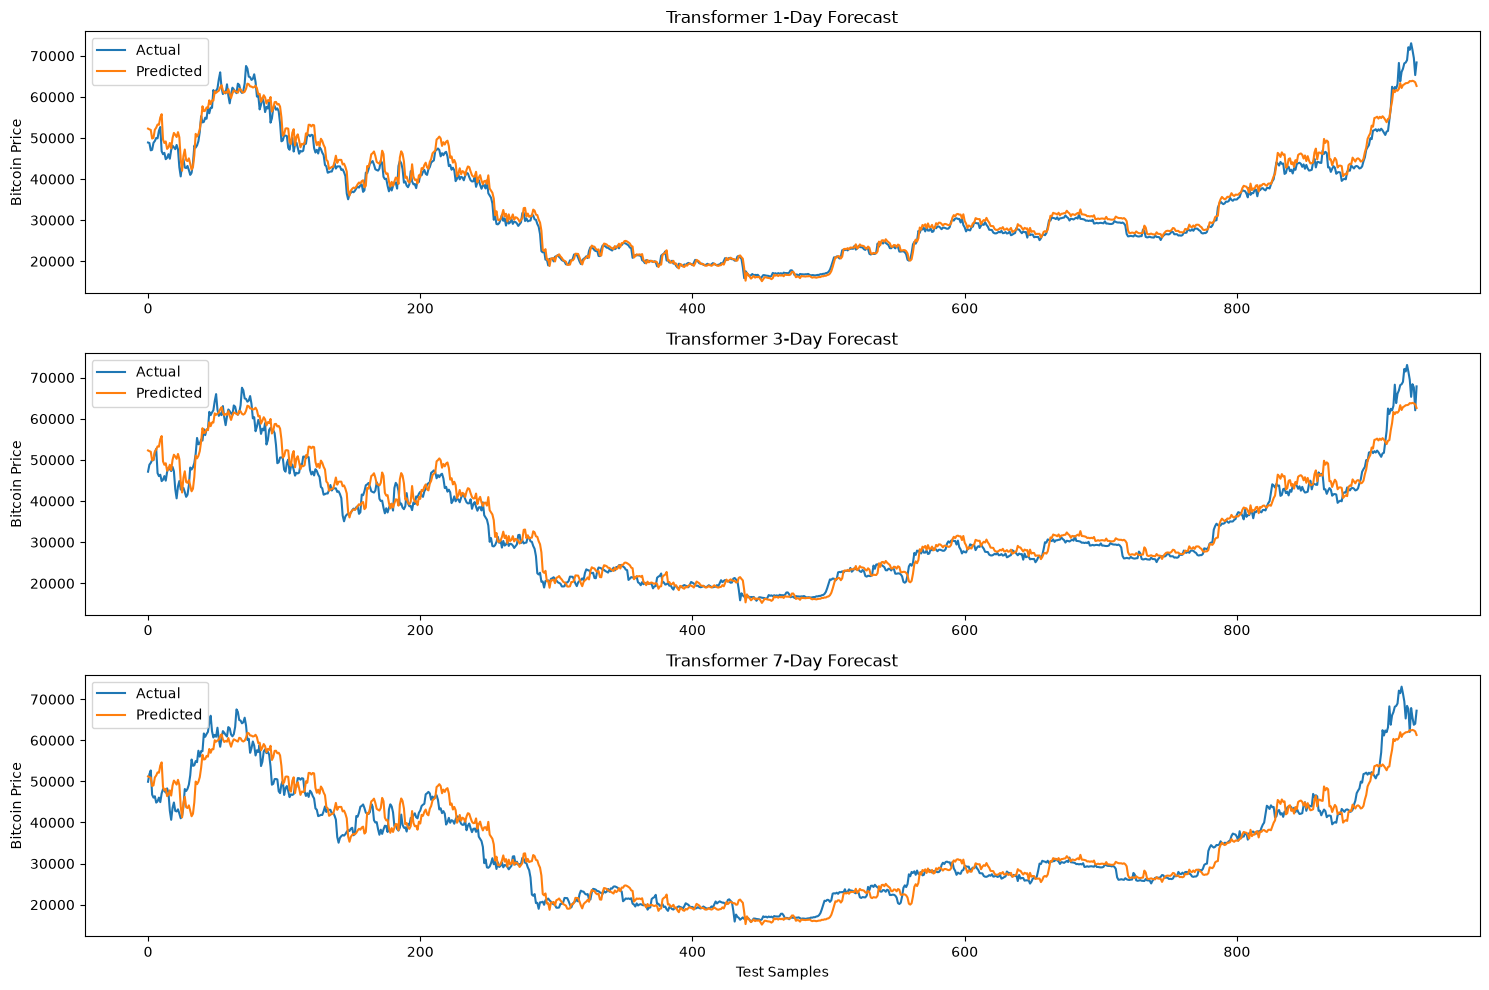

In [53]:
#Transformer Visualization

plt.figure(figsize=(15,10))

# 1-Day 
plt.subplot(3,1,1)
plt.plot(actual_1d_TRANS, label="Actual")
plt.plot(pred_1d_TRANS, label="Predicted")
plt.title("Transformer 1-Day Forecast")
plt.ylabel("Bitcoin Price")
plt.legend()

# 3-Day 
plt.subplot(3,1,2)
plt.plot(actual_3d_TRANS, label="Actual")
plt.plot(pred_3d_TRANS, label="Predicted")
plt.title("Transformer 3-Day Forecast")
plt.ylabel("Bitcoin Price")
plt.legend()

# 7-Day 
plt.subplot(3,1,3)
plt.plot(actual_7d_TRANS, label="Actual")
plt.plot(pred_7d_TRANS, label="Predicted")
plt.title("Transformer 7-Day Forecast")
plt.xlabel("Test Samples")
plt.ylabel("Bitcoin Price")
plt.legend()

plt.tight_layout()
plt.show()

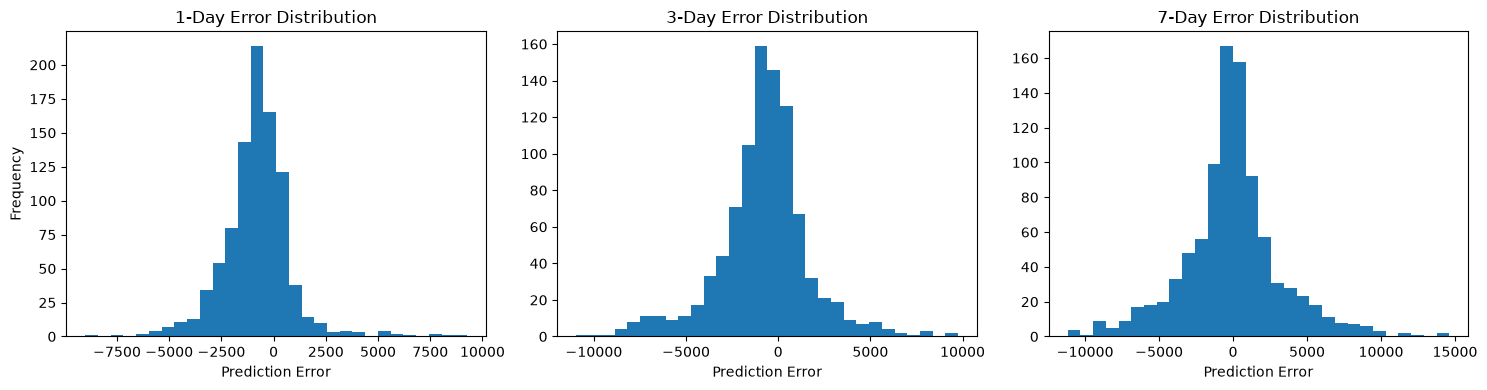

In [56]:
#Transformer Error distribution plot

error_1d_TRANS = actual_1d_TRANS.flatten() - pred_1d_TRANS.flatten()
error_3d_TRANS = actual_3d_TRANS.flatten() - pred_3d_TRANS.flatten()
error_7d_TRANS = actual_7d_TRANS.flatten() - pred_7d_TRANS.flatten()

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(error_1d_TRANS, bins=30)
plt.title("1-Day Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.subplot(1,3,2)
plt.hist(error_3d_TRANS, bins=30)
plt.title("3-Day Error Distribution")
plt.xlabel("Prediction Error")

plt.subplot(1,3,3)
plt.hist(error_7d_TRANS, bins=30)
plt.title("7-Day Error Distribution")
plt.xlabel("Prediction Error")

plt.tight_layout()
plt.show()

In [61]:
#Models comparison
results = pd.DataFrame({
    "Model": ["LSTM","RNN","CNN","Transformer"],
    
    "1-Day MAE": [mae_1_LSTM,mae_1_RNN,mae_1_CNN,mae_1_TRANS],
    "1-Day RMSE": [rmse_1_LSTM,rmse_1_RNN,rmse_1_CNN,rmse_1_TRANS],
    "1-Day R²": [r2_1_LSTM,r2_1_RNN,r2_1_CNN,r2_1_TRANS],

    "3-Day MAE":  [mae_3_LSTM,mae_3_RNN,mae_3_CNN,mae_3_TRANS],
    "3-Day RMSE": [rmse_3_LSTM,rmse_3_RNN,rmse_3_CNN,rmse_3_TRANS],
    "3-Day R²": [r2_3_LSTM,r2_3_RNN,r2_3_CNN,r2_3_TRANS],

    "7-Day MAE": [mae_7_LSTM,mae_7_RNN,mae_7_CNN,mae_7_TRANS],
    "7-Day RMSE": [rmse_7_LSTM,rmse_7_RNN,rmse_7_CNN,rmse_7_TRANS],
    "7-Day R²": [r2_7_LSTM,r2_7_RNN,r2_7_CNN,r2_7_TRANS]

})

print(results)

         Model    1-Day MAE   1-Day RMSE  1-Day R²    3-Day MAE   3-Day RMSE  \
0         LSTM  1166.456297  1553.095101  0.985525  1813.247103  2463.031628   
1          RNN  1055.840820  1414.684285  0.987990  1639.615234  2303.604784   
2          CNN  4279.875000  5006.478603  0.849582  5060.745605  5800.932684   
3  Transformer  1310.579590  1827.019362  0.979968  1844.724365  2604.753251   

   3-Day R²    7-Day MAE   7-Day RMSE  7-Day R²  
0  0.964165  2566.181781  3451.117092  0.930971  
1  0.968654  2219.378174  3223.059571  0.939792  
2  0.801226  5762.626953  6576.779759  0.749308  
3  0.959923  2322.628662  3315.566317  0.936287  


In [62]:
results.to_csv("Model_Comparison.csv", index=False)

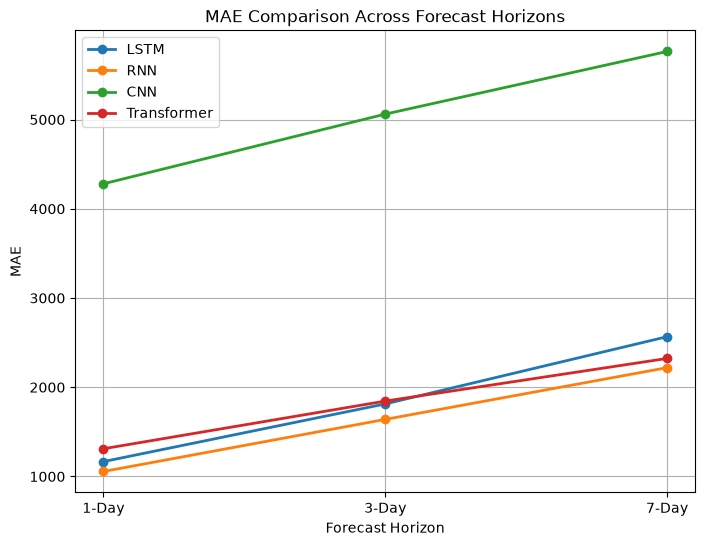

In [63]:
#MAE across horizon comparison
plt.figure(figsize=(8,6))

plt.plot(["1-Day","3-Day","7-Day"],
         [1166.46,1813.25,2566.18],
         marker='o',
         linewidth=2,
         label="LSTM")

plt.plot(["1-Day","3-Day","7-Day"],
         [1055.84,1639.62,2219.38],
         marker='o',
         linewidth=2,
         label="RNN")

plt.plot(["1-Day","3-Day","7-Day"],
         [4279.88,5060.75,5762.63],
         marker='o',
         linewidth=2,
         label="CNN")

plt.plot(["1-Day","3-Day","7-Day"],
         [1310.58,1844.72,2322.63],
         marker='o',
         linewidth=2,
         label="Transformer")

plt.xlabel("Forecast Horizon")

plt.ylabel("MAE")

plt.title("MAE Comparison Across Forecast Horizons")

plt.legend()

plt.grid(True)

plt.show()

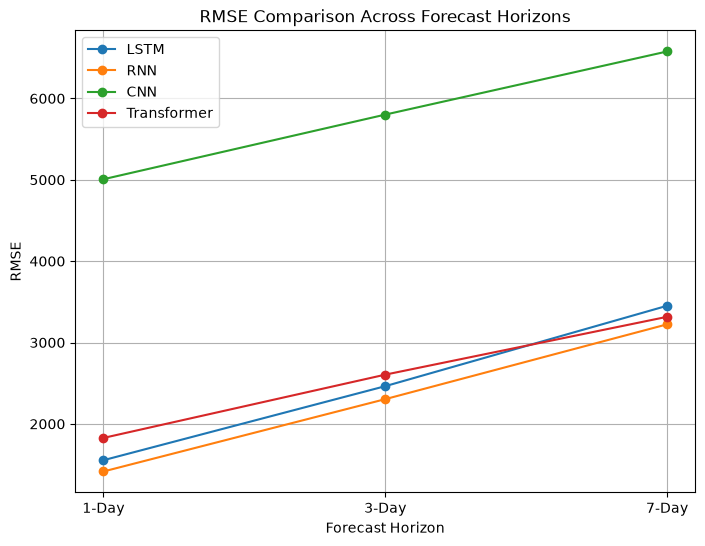

In [64]:
#RSME across horizon comparison
plt.figure(figsize=(8,6))

plt.plot(["1-Day","3-Day","7-Day"],
         [1553.10,2463.03,3451.12],
         marker='o',
         label="LSTM")

plt.plot(["1-Day","3-Day","7-Day"],
         [1414.68,2303.60,3223.06],
         marker='o',
         label="RNN")

plt.plot(["1-Day","3-Day","7-Day"],
         [5006.48,5800.93,6576.78],
         marker='o',
         label="CNN")

plt.plot(["1-Day","3-Day","7-Day"],
         [1827.02,2604.75,3315.57],
         marker='o',
         label="Transformer")

plt.xlabel("Forecast Horizon")

plt.ylabel("RMSE")

plt.title("RMSE Comparison Across Forecast Horizons")

plt.legend()

plt.grid(True)

plt.show()

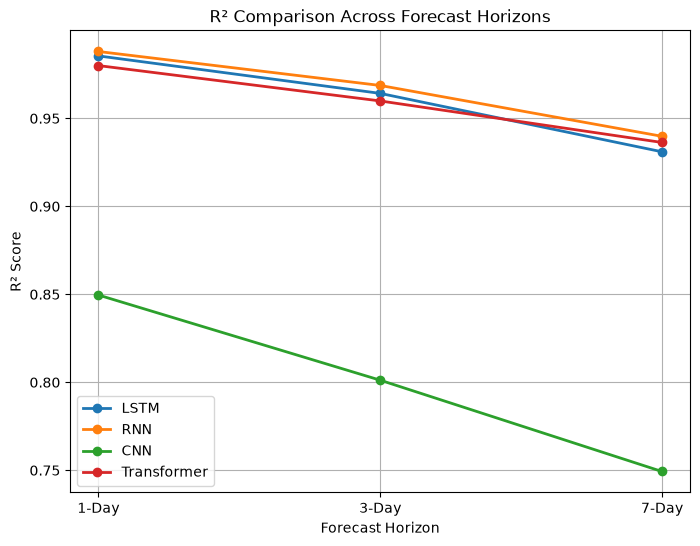

In [65]:
#R2 across horizon comparison
plt.figure(figsize=(8,6))

plt.plot(["1-Day","3-Day","7-Day"],
         [0.9855,0.9642,0.9310],
         marker='o',
         linewidth=2,
         label="LSTM")

plt.plot(["1-Day","3-Day","7-Day"],
         [0.9880,0.9687,0.9398],
         marker='o',
         linewidth=2,
         label="RNN")

plt.plot(["1-Day","3-Day","7-Day"],
         [0.8496,0.8012,0.7493],
         marker='o',
         linewidth=2,
         label="CNN")

plt.plot(["1-Day","3-Day","7-Day"],
         [0.9800,0.9599,0.9363],
         marker='o',
         linewidth=2,
         label="Transformer")

plt.xlabel("Forecast Horizon")

plt.ylabel("R² Score")

plt.title("R² Comparison Across Forecast Horizons")

plt.legend()

plt.grid(True)

plt.show()